In [1]:
import pandas as pd

path = "/content/drive/MyDrive/Policing Project/Datasets/traffic_analysis.csv"
df = pd.read_csv(path)

df.shape
df.head()

/tmp/ipykernel_216/3739962403.py:4: DtypeWarning: Columns (12,13,18,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,raw_row_number,date,time,location,lat,lng,geocode_source,beat,district,subject_age,...,trust_in_local_government,trust_in_local_government_rate,economic_diversity_index,hardship_index,median_household_income,poverty_rate,foreign_born,limited_english_proficiency,demographics,population
0,4,2012-01-01,01:00:00,108 LAMON AVE N,41.882072,-87.747829,SU,NaN,NaN,35.0,...,29600.0,39.844682,0.775025,85.469151,51826.851402,23.399157,10.704508,8.804414,5.533701,97671.110800
1,9,2012-01-01,01:00:00,430 STATE ST N,41.890322,-87.628217,GM,NaN,NaN,26.0,...,34700.0,39.185753,0.354411,3.402425,125101.326886,9.622478,18.181435,4.297681,66.267215,99292.486072
2,11,2012-01-01,01:00:00,4225 ARMITAGE AVE W,41.916806,-87.732301,GM,NaN,NaN,26.0,...,12900.0,53.921078,0.798612,77.967935,70459.881153,13.674981,34.878304,36.024369,9.575501,22644.717836
3,18,2012-01-01,03:00:00,1011 GARFIELD BLVD W,41.793582,-87.650526,GM,NaN,NaN,22.0,...,4800.0,27.250549,0.728528,93.089143,32084.861861,33.435182,5.675052,5.465415,1.005840,23160.939521
4,20,2012-01-01,02:00:00,13455 MACKINAW AVE S,41.650292,-87.542070,GM,NaN,NaN,21.0,...,2100.0,28.253638,0.802099,68.392927,61745.599215,9.820789,14.676821,11.130220,35.767045,8767.938562


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [3]:
# parse date + time
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S', errors='coerce').dt.time

# numeric fields
num_cols = ['subject_age','officer_years_of_service','lat','lng']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# booleans
bool_cols = ['citation_issued','search_conducted','search_person','search_vehicle']
for c in bool_cols:
    df[c] = df[c].astype('float')  # avoids seaborn errors

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258561 entries, 0 to 1258560
Data columns (total 45 columns):
 #   Column                                Non-Null Count    Dtype         
---  ------                                --------------    -----         
 0   raw_row_number                        1258561 non-null  int64         
 1   date                                  1258561 non-null  datetime64[ns]
 2   time                                  1258561 non-null  object        
 3   location                              1258561 non-null  object        
 4   lat                                   1258561 non-null  float64       
 5   lng                                   1258561 non-null  float64       
 6   geocode_source                        1258561 non-null  object        
 7   beat                                  1178425 non-null  float64       
 8   district                              1178425 non-null  float64       
 9   subject_age                           1244362 

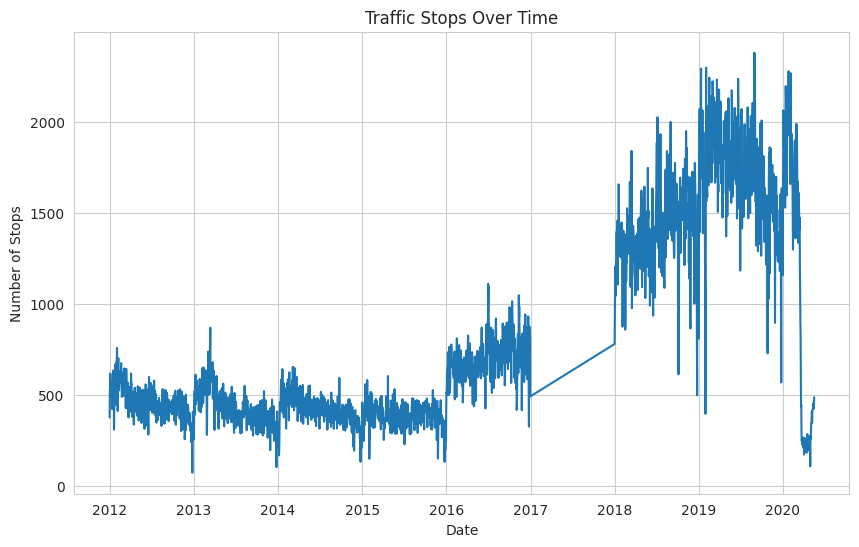

In [ ]:
stops_by_day = df.groupby(df['date'].dt.date).size()

stops_by_day.plot()
plt.title("Traffic Stops Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Stops")
plt.show()

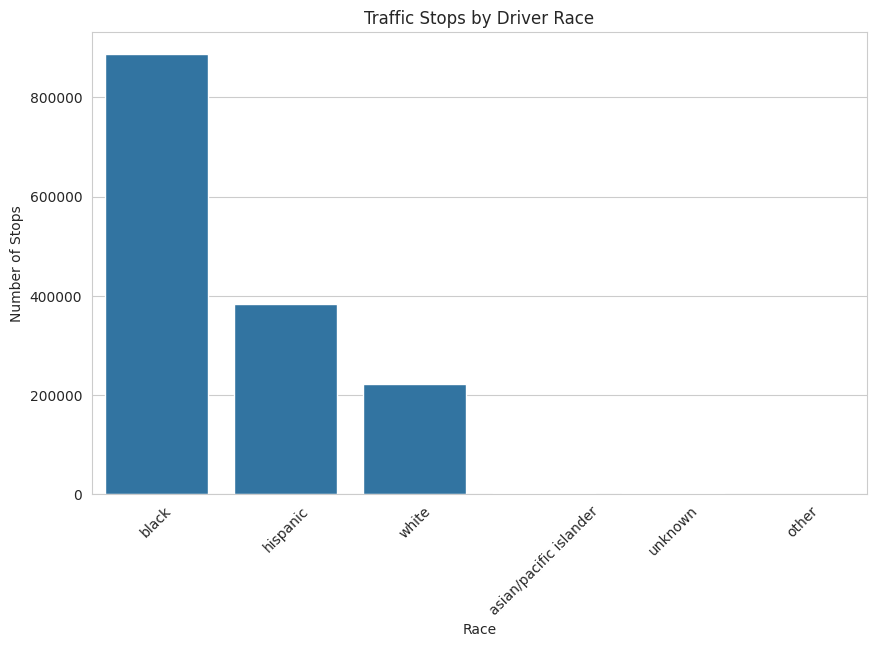

In [ ]:
sns.countplot(data=df, x='subject_race', order=df['subject_race'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Traffic Stops by Driver Race")
plt.xlabel("Race")
plt.ylabel("Number of Stops")
plt.show()

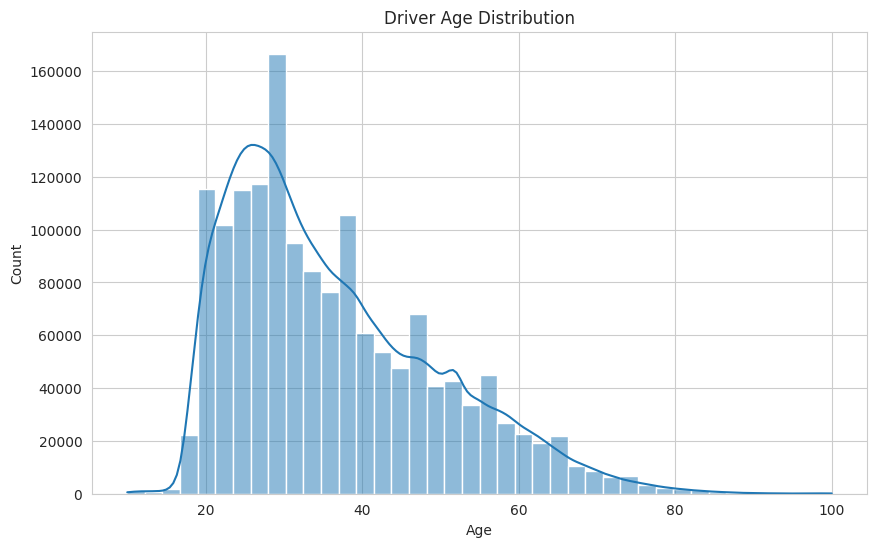

In [ ]:
sns.histplot(df['subject_age'], bins=40, kde=True)
plt.title("Driver Age Distribution")
plt.xlabel("Age")
plt.show()

DTypePromotionError: The DType <class 'numpy.dtypes._PyFloatDType'> could not be promoted by <class 'numpy.dtypes.StrDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyFloatDType'>)

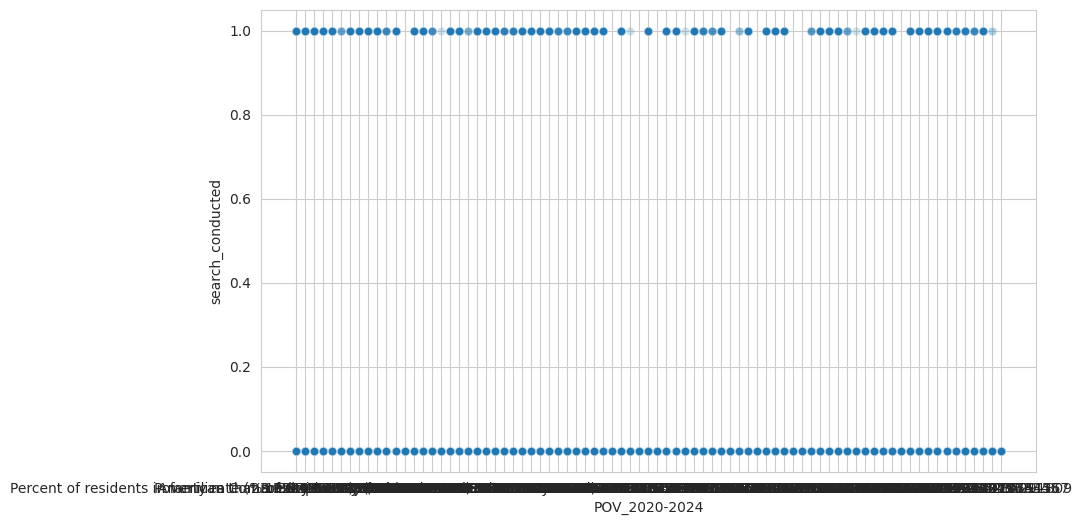

In [ ]:
sns.scatterplot(data=df, x='POV_2020-2024', y='search_conducted', alpha=0.2)
sns.regplot(data=df, x='POV_2020-2024', y='search_conducted', scatter=False, color='red')

plt.title("Neighborhood Poverty vs Search Probability")
plt.xlabel("Neighborhood Poverty Rate")
plt.ylabel("Search Conducted")
plt.show()